Predicted Label: Horse


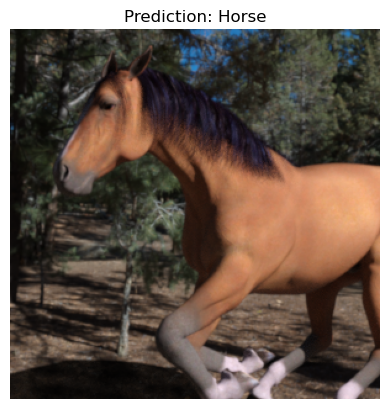

In [3]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# HOG Feature Extraction
def extract_hog_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized_img = cv2.resize(gray, (128, 128))
    hog_features, _ = hog(resized_img, orientations=9, pixels_per_cell=(8, 8),
                          cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
    return hog_features

# SIFT Feature Extraction
def extract_sift_features(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    if descriptors is None:
        return np.zeros(128)  # Return zero vector if no features are found
    descriptors = descriptors.flatten()
    return descriptors[:128] if descriptors.shape[0] >= 128 else np.pad(descriptors, (0, 128 - descriptors.shape[0]), 'constant')

# Combine HOG + SIFT Features
def extract_features(image):
    hog_feat = extract_hog_features(image)
    sift_feat = extract_sift_features(image)
    return np.hstack((hog_feat, sift_feat))

# Load Dataset
def load_dataset(horses_folder, humans_folder):
    features, labels = [], []
    for folder, label in [(horses_folder, 0), (humans_folder, 1)]:  # 0 = Horse, 1 = Human
        for file_name in os.listdir(folder):
            image_path = os.path.join(folder, file_name)
            image = cv2.imread(image_path)
            if image is None:
                continue  # Skip unreadable images
            features.append(extract_features(image))
            labels.append(label)
    return np.array(features), np.array(labels)

# Image Classification
def classify_image(model, scaler, pca, image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Could not read image.")
        return
    features = extract_features(image)
    features = scaler.transform([features])
    features = pca.transform(features)
    prediction = model.predict(features)[0]
    label_text = "Horse" if prediction == 0 else "Human"
    print(f"Predicted Label: {label_text}")
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label_text}")
    plt.axis("off")
    plt.show()

# Dataset Paths
horses_folder = r"C:\Users\moune\Downloads\horse-or-human\horses"
humans_folder = r"C:\Users\moune\Downloads\horse-or-human\humans"

# Load Data
X, y = load_dataset(horses_folder, humans_folder)

# Preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100)  # Reduce dimensionality
X_pca = pca.fit_transform(X_scaled)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train SVM Classifier
svm_classifier = SVC(kernel='linear', probability=True)
svm_classifier.fit(X_train, y_train)

# Test with an Image
image_path = r"C:\Users\moune\Downloads\horse-or-human\horses\horse50-7.png" # Change this to your test image
classify_image(svm_classifier, scaler, pca, image_path)
